/tmp/ipykernel_1535/3984470906.py:82: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle((x, y), size, color=color, alpha=0.8, zorder=3, edgecolor="white", linewidth=2)


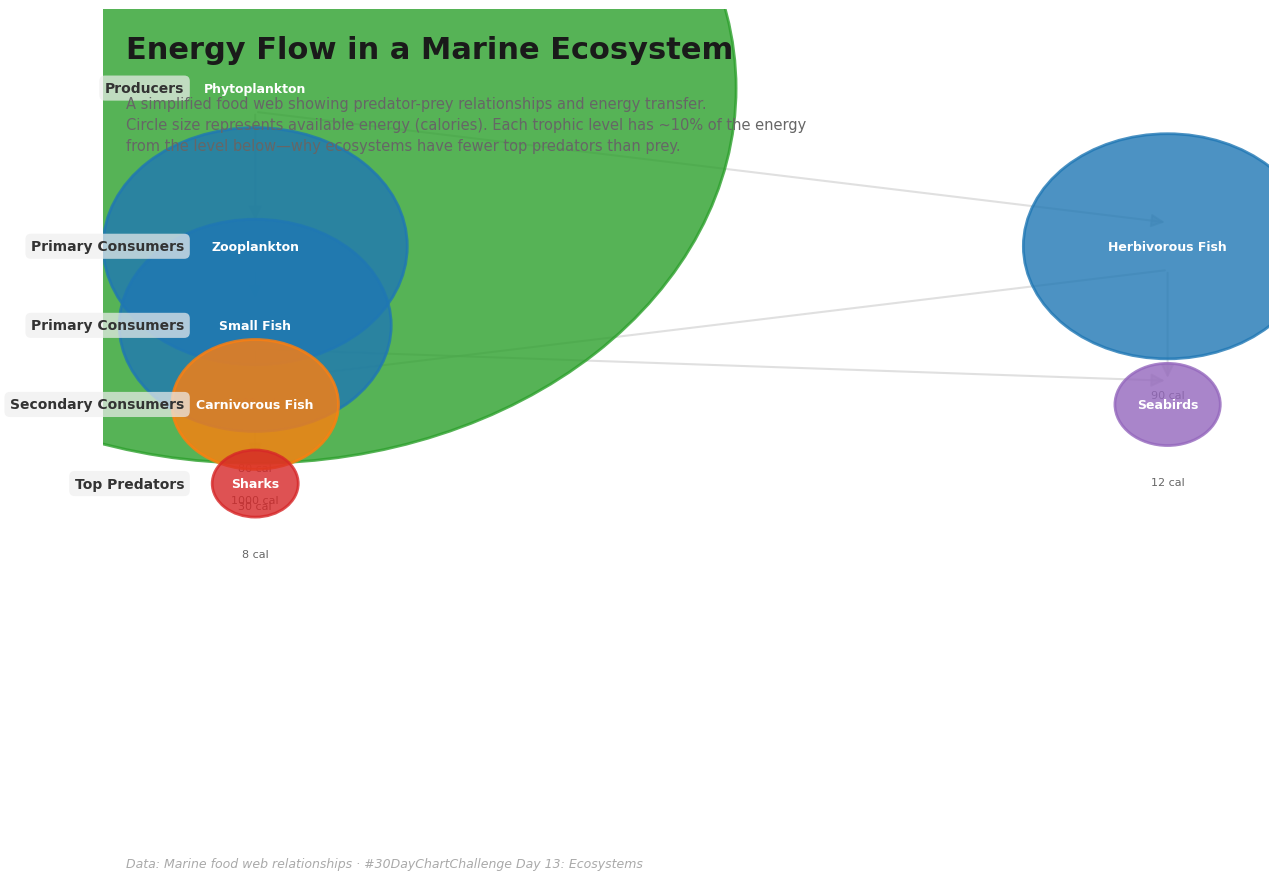

In [1]:
"""
#30DayChartChallenge — Day 13: Ecosystems
"Food Web: Energy Flow in a Marine Ecosystem" — ecosystem relationships
in the style of FlowingData: minimal chrome, direct labels, clean typography.

Data: Simplified marine food web with energy transfer
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# ---------------------------------------------------------------------------
# 1. ECOSYSTEM STRUCTURE — Marine food web
# ---------------------------------------------------------------------------
# Organisms: (name, trophic_level, energy_calories)
organisms = {
    "Phytoplankton": {"level": 0, "energy": 1000, "color": "#2ca02c"},
    "Zooplankton": {"level": 1, "energy": 100, "color": "#1f77b4"},
    "Small Fish": {"level": 1.5, "energy": 80, "color": "#1f77b4"},
    "Herbivorous Fish": {"level": 1, "energy": 90, "color": "#1f77b4"},
    "Carnivorous Fish": {"level": 2, "energy": 30, "color": "#ff7f0e"},
    "Sharks": {"level": 2.5, "energy": 8, "color": "#d62728"},
    "Seabirds": {"level": 2, "energy": 12, "color": "#9467bd"},
}

# Energy flow relationships (predator <- prey)
flows = [
    ("Zooplankton", "Phytoplankton"),
    ("Small Fish", "Zooplankton"),
    ("Herbivorous Fish", "Phytoplankton"),
    ("Carnivorous Fish", "Small Fish"),
    ("Carnivorous Fish", "Herbivorous Fish"),
    ("Sharks", "Carnivorous Fish"),
    ("Seabirds", "Small Fish"),
    ("Seabirds", "Herbivorous Fish"),
]

# ---------------------------------------------------------------------------
# 2. PLOT — Hierarchical food web
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 9), facecolor="#FFFFFF")
ax.set_facecolor("#FFFFFF")

# Position organisms by trophic level
positions = {}
level_counts = {}

for org, data in organisms.items():
    level = data["level"]
    if level not in level_counts:
        level_counts[level] = []
    level_counts[level].append(org)

# Assign x, y coordinates
y_spacing = 2
for level, orgs in level_counts.items():
    x_positions = np.linspace(1, 10, len(orgs))
    y = 10 - (level * y_spacing)
    for i, org in enumerate(orgs):
        positions[org] = (x_positions[i], y)

# Draw energy flow arrows
for predator, prey in flows:
    x1, y1 = positions[prey]
    x2, y2 = positions[predator]
    
    # Arrow from prey to predator
    arrow = FancyArrowPatch((x1, y1 - 0.3), (x2, y2 + 0.3),
                           arrowstyle="-|>", mutation_scale=20,
                           linewidth=1.5, color="#cccccc", alpha=0.6, zorder=1)
    ax.add_patch(arrow)

# Draw organism nodes
for org, (x, y) in positions.items():
    energy = organisms[org]["energy"]
    color = organisms[org]["color"]
    
    # Circle size proportional to energy
    size = np.sqrt(energy) * 0.15
    circle = plt.Circle((x, y), size, color=color, alpha=0.8, zorder=3, edgecolor="white", linewidth=2)
    ax.add_patch(circle)
    
    # Label
    ax.text(x, y, org, fontsize=9, fontweight="600", color="white",
            ha="center", va="center", zorder=4)
    
    # Energy value below
    ax.text(x, y - size - 0.4, f"{energy} cal", fontsize=8, color="#666666",
            ha="center", va="top", fontweight="500")

# Trophic level labels
trophic_labels = {
    0: "Producers",
    1: "Primary Consumers",
    1.5: "Primary Consumers",
    2: "Secondary Consumers",
    2.5: "Top Predators"
}

y_labels = 10 - np.array(list(level_counts.keys())) * y_spacing
for level in sorted(level_counts.keys()):
    y = 10 - (level * y_spacing)
    ax.text(0.3, y, trophic_labels[level], fontsize=10, fontweight="600",
            color="#333333", ha="right", va="center",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#eeeeee", edgecolor="none", alpha=0.7))

# Minimal styling
ax.set_xlim(-0.5, 11)
ax.set_ylim(0, 11)
ax.axis("off")

# Title & subtitle
ax.text(0.02, 0.97, "Energy Flow in a Marine Ecosystem",
        fontsize=22, fontweight="bold", color="#1a1a1a", transform=ax.transAxes, va="top")

ax.text(0.02, 0.90,
        "A simplified food web showing predator-prey relationships and energy transfer.\n"
        "Circle size represents available energy (calories). Each trophic level has ~10% of the energy\n"
        "from the level below—why ecosystems have fewer top predators than prey.",
        fontsize=10.5, color="#666666", transform=ax.transAxes, va="top", linespacing=1.5)

# Source
ax.text(0.02, 0.01,
        "Data: Marine food web relationships · #30DayChartChallenge Day 13: Ecosystems",
        fontsize=9, color="#aaaaaa", style="italic", transform=ax.transAxes, va="bottom")

plt.tight_layout()
plt.savefig("day13_ecosystems.png", dpi=200, facecolor="#FFFFFF", bbox_inches="tight")
plt.show()